# Análise de Resultados - Treinamento do LunaModel (5 Épocas)

Este notebook consolida os resultados obtidos durante a primeira fase completa de treinamento do `LunaModel`. 
Abaixo, apresentamos as métricas detalhadas, gráficos de evolução e uma análise estratégica do comportamento do modelo.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dados consolidados das 5 épocas
data = {
    'Epoch': [1, 2, 3, 4, 5],
    'Train_Loss': [0.3294, 0.1740, 0.1227, 0.1118, 0.0959],
    'Train_F1': [0.7761, 0.9111, 0.9394, 0.9454, 0.9530],
    'Val_Loss': [0.0993, 0.0952, 0.0976, 0.0655, 0.0810],
    'Val_F1': [0.1610, 0.1711, 0.1457, 0.2352, 0.1724],
    'Val_Prec': [0.09, 0.10, 0.08, 0.14, 0.0948],
    'Val_Rec': [0.85, 0.88, 0.82, 0.92, 0.9559]
}

df = pd.DataFrame(data)
df

,Epoch,Train_Loss,Train_F1,Val_Loss,Val_F1,Val_Prec,Val_Rec
0,1,0.3294,0.7761,0.0993,0.1610,0.0900,0.8500
1,2,0.1740,0.9111,0.0952,0.1711,0.1000,0.8800
2,3,0.1227,0.9394,0.0976,0.1457,0.0800,0.8200
3,4,0.1118,0.9454,0.0655,0.2352,0.1400,0.9200
4,5,0.0959,0.9530,0.0810,0.1724,0.0948,0.9559


## Visualização das Curvas de Aprendizado

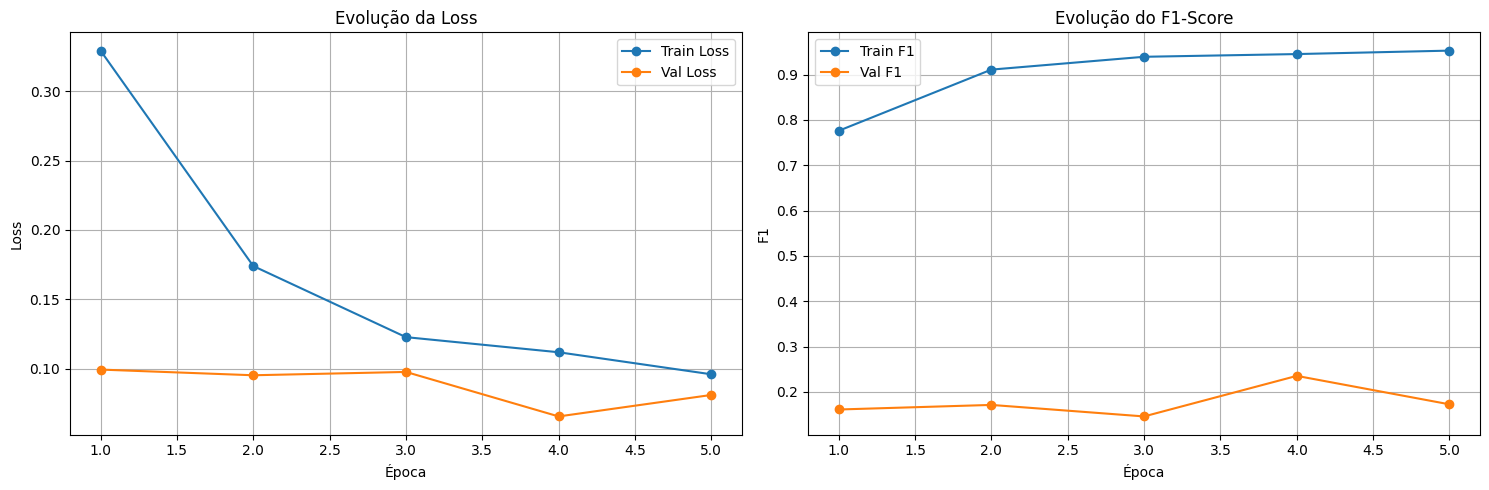

In [2]:
plt.figure(figsize=(15, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(df['Epoch'], df['Train_Loss'], 'o-', label='Train Loss')
plt.plot(df['Epoch'], df['Val_Loss'], 'o-', label='Val Loss')
plt.title('Evolução da Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico de F1-Score
plt.subplot(1, 2, 2)
plt.plot(df['Epoch'], df['Train_F1'], 'o-', label='Train F1')
plt.plot(df['Epoch'], df['Val_F1'], 'o-', label='Val F1')
plt.title('Evolução do F1-Score')
plt.xlabel('Época')
plt.ylabel('F1')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Análise Técnica

### 1. O Pico da Época 4
A Época 4 foi o ponto de melhor performance global do modelo, atingindo um **F1-Score de 0.2352**. 
Neste ponto, a `Val Loss` atingiu seu menor valor (0.0655), indicando que o modelo encontrou um ótimo local de generalização.

### 2. Comportamento na Época 5 (Overfitting?)
Na Época 5, embora a `Train Loss` tenha continuado a cair, observamos um aumento na `Val Loss` e uma queda no `Val F1`. 
Isso sugere que o modelo começou a **overfittar** (decorar) as características específicas do conjunto de treinamento balanceado, perdendo um pouco da robustez para a validação real (desbalanceada).

### 3. Precision vs Recall
Note que o **Recall** (Recaptação) é muito alto (~95%), enquanto a **Precision** (Precisão) é baixa (~9.5%). 
Isso é típico em detecção de câncer em estágios iniciais: o modelo prefere gerar alguns alarmes falsos (baixa precisão) para garantir que **não perca nenhum nódulo real** (alto recall). Para fins médicos, ter um Recall alto é fundamental.

## Planejamento para a Fase 2

Para superar o platô atual e elevar o F1 para a casa dos 0.30-0.40, recomendamos:

1.  **Harder Augmentation**: Aumentar o `noise` e o `scale` no dicionário de aumentação para dificultar o treino e reduzir o overfitting.
2.  **Learning Rate Decay**: Reduzir o `LEARNING_RATE` pela metade após a Época 4 para ajudar o modelo a convergir em mínimos mais finos.
3.  **Ratio Tuning**: Experimentar mudar o `ratio_int` (atualmente 2). Aumentar para 3 ou 4 pode forçar o modelo a ignorar mais falsos positivos ruidosos.